#1 - Loading Data

In [1]:
import kagglehub

path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv(path + "/spam.csv", encoding="latin-1")
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.shape

(5572, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


#2 - Data Cleaning

## 2.1 - Create and remove Labels

In [6]:
df.drop(columns=["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], inplace=True)


In [7]:
df.rename(columns={"v1": "target", "v2": "message"}, inplace=True)

In [8]:
df.sample(6)

,target,message
2568,ham,Hey. For me there is no leave on friday. Wait ...
3921,ham,"Oh really? perform, write a paper, go to a mov..."
1801,ham,I wanna watch that movie
4124,ham,May b approve panalam...but it should have mor...
1025,ham,I have a sore throat. It's scratches when I talk
5079,ham,\Keep ur problems in ur heart


In [9]:
df['target'].value_counts()

,count
target,
ham,4825
spam,747


##2.2 - Label Encoding

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

#ham - 0
#spam - 1

,target,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


##2.3 - Missing Values

In [11]:
df.isnull().sum()

,0
target,0
message,0


##2.4 - Duplicate Values

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df.drop_duplicates(inplace=True, keep = 'first')

In [14]:
df.shape

(5169, 2)

In [15]:
df.tail()

,target,message
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...
5571,0,Rofl. Its true to its name


#3 - EDA

In [16]:
df['target'].value_counts()

,count
target,
0,4516
1,653


##3.1 - Spam vs Ham - Pie Chart

In [17]:
import matplotlib.pyplot as plt


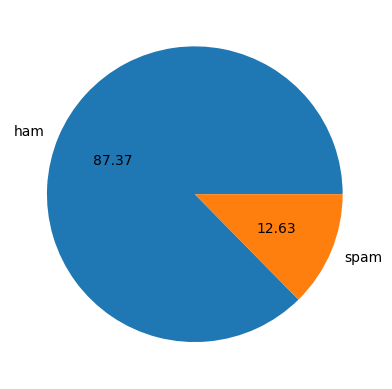

In [18]:
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

## 3.2 - Get Total Words, Chars, Sentences

In [19]:
!pip install nltk

In [20]:
import nltk

In [21]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [22]:
#Extract total characters

df['message'].apply(len)

,message
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


In [23]:
df['total_characters'] = df['message'].apply(len)

In [24]:
df.head()

,target,message,total_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [25]:
#Get Number of Words

df['message'].apply(lambda x: (nltk.word_tokenize(x)))

,message
0,"[Go, until, jurong, point, ,, crazy, .., Avail..."
1,"[Ok, lar, ..., Joking, wif, u, oni, ...]"
2,"[Free, entry, in, 2, a, wkly, comp, to, win, F..."
3,"[U, dun, say, so, early, hor, ..., U, c, alrea..."
4,"[Nah, I, do, n't, think, he, goes, to, usf, ,,..."
...,...
5567,"[This, is, the, 2nd, time, we, have, tried, 2,..."
5568,"[Will, Ì_, b, going, to, esplanade, fr, home, ?]"
5569,"[Pity, ,, *, was, in, mood, for, that, ., So, ..."
5570,"[The, guy, did, some, bitching, but, I, acted,..."


In [26]:
df['total_words'] = df['message'].apply(lambda x: len(nltk.word_tokenize(x)))

In [27]:
df.head()

,target,message,total_characters,total_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [28]:
#Get Number of sentences
df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

,message
0,2
1,2
2,2
3,1
4,1
...,...
5567,4
5568,1
5569,2
5570,1


In [29]:
df['total_sentences'] = df['message'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [30]:
df.head()

,target,message,total_characters,total_words,total_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [31]:
df[['total_characters', 'total_words', 'total_sentences']].describe()

,total_characters,total_words,total_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


## 3.3 - spam vs ham - Histogram

In [32]:
import seaborn as sns

<Axes: xlabel='total_characters', ylabel='Count'>

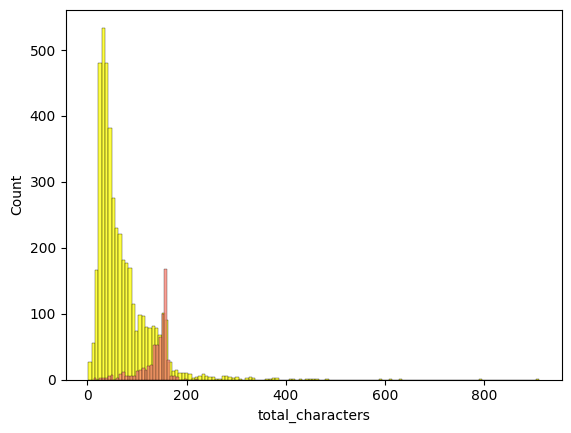

In [33]:
sns.histplot(df[df['target'] == 0]['total_characters'], color='yellow')
sns.histplot(df[df['target'] == 1]['total_characters'], color = 'salmon')

##3.4 - Pairplot

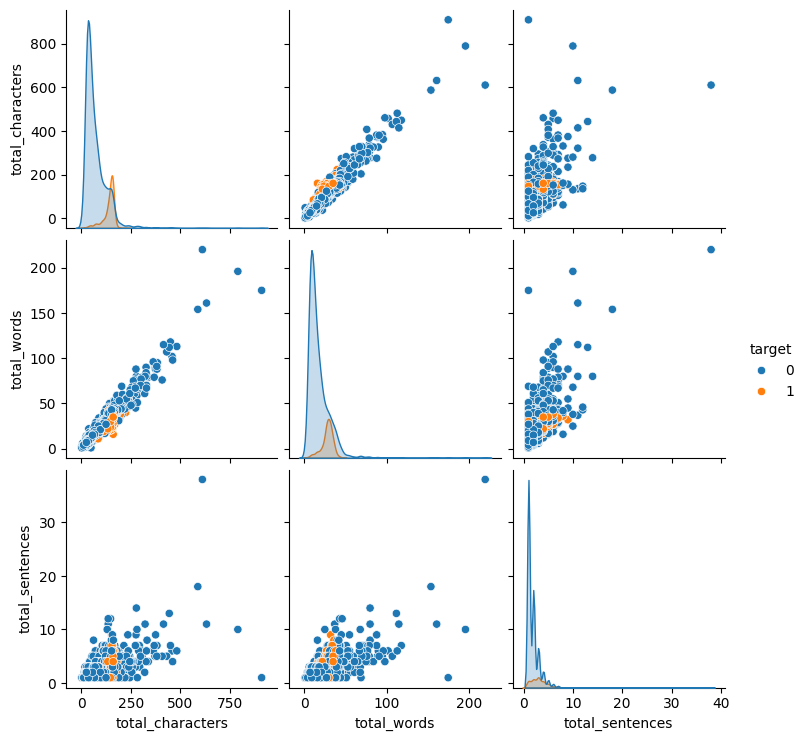

In [34]:
sns.pairplot(df, hue = 'target')

##3.5 - Correlation heatmap

<Axes: >

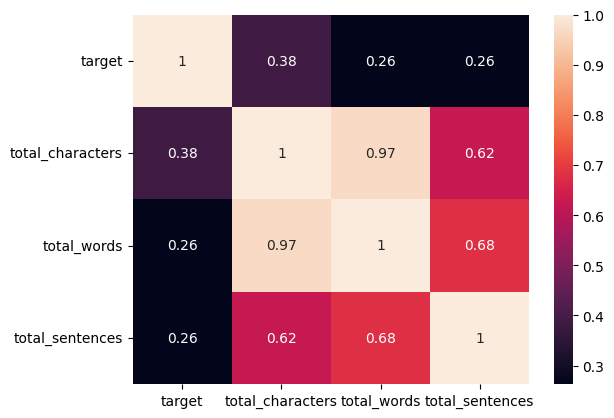

In [35]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

#4 - Data Pre-Processing


* Lower Case
* Tokenisation
* Removing Special Characters
* Removing Stop words
* Removing Punctuations
* Stemming



##4.1 - Transform function

In [36]:
def transform_message(text):

    # 1. Lower Case.
    text = text.lower()

    # 2. tokenisation
    text = nltk.word_tokenize(text)

    # 3. Removing Special Characters
    words = []
    for char in text:
        if char.isalnum():
            words.append(char)

    # 4, 5. Removing Stop words and punctuations
    text = words[:]
    words.clear()

    for word in text:
        if (word not in stopwords.words('english')) and (word not in string.punctuation):
            words.append(word)

    # 6. Stemming
    text = words[:]
    words.clear()

    for word in text:
        stemmed_word = ps.stem(word)
        words.append(stemmed_word)


    return " ".join(words)

In [37]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [38]:
import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')
from nltk.corpus import stopwords
stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

##4.2 - Test and Imports

In [41]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('Glowing')

'glow'

In [42]:
transform_message("I'm going to be home soon and % here # and @ 123 !")

'go home soon 123'

##4.3 - Apply Transform Function

In [43]:
df['transformed_message'] = df['message'].apply(transform_message)

In [44]:
df.head()

,target,message,total_characters,total_words,total_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


##4.4 - Word Cloud of Ham and Spam

In [45]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [46]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_message'].str.cat(sep=" "))

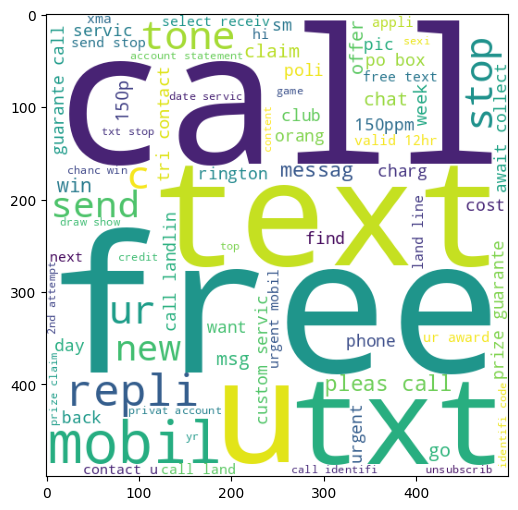

In [47]:
plt.figure(figsize=(15, 6))
plt.imshow(spam_wc)

In [48]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_message'].str.cat(sep=" "))

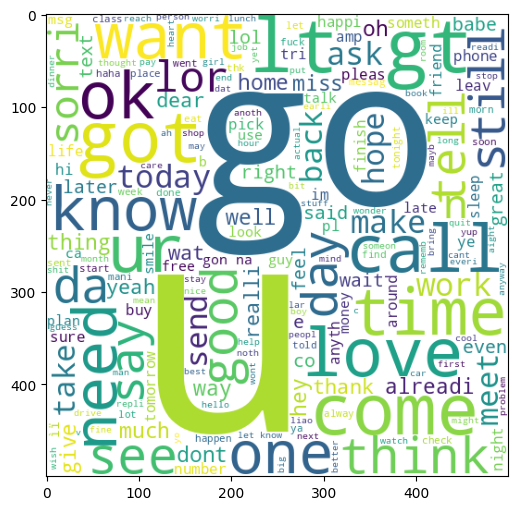

In [49]:
plt.figure(figsize=(15, 6))
plt.imshow(ham_wc)

In [50]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_message'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

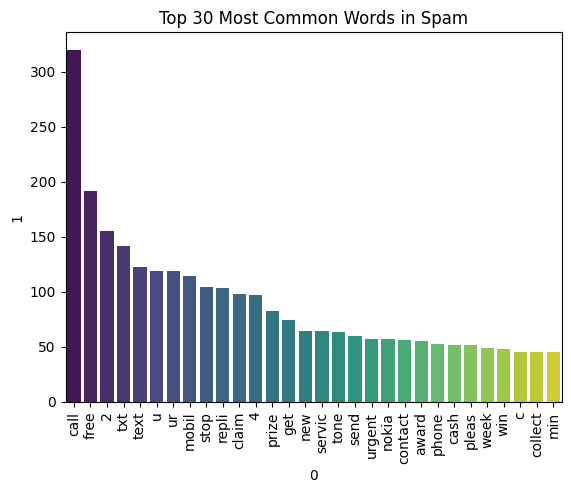

In [51]:
from collections import Counter

most_common_spam = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=most_common_spam[0], y=most_common_spam[1], hue=most_common_spam[0], palette='viridis', legend=False)
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Common Words in Spam')
plt.show()

In [52]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_message'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)

35404

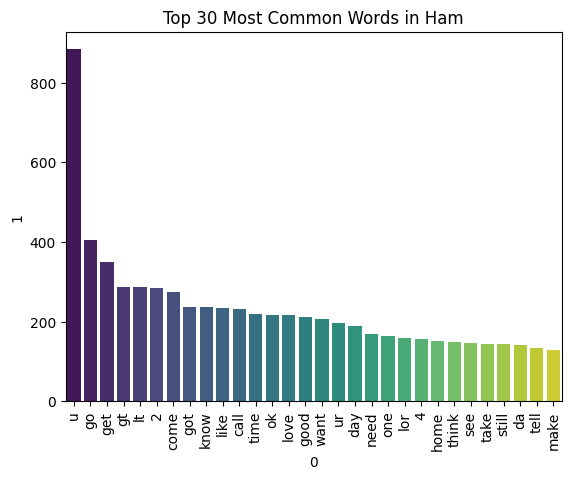

In [53]:
from collections import Counter

most_common_ham = pd.DataFrame(Counter(ham_corpus).most_common(30))

sns.barplot(x=most_common_ham[0], y=most_common_ham[1], hue=most_common_ham[0], palette='viridis', legend=False)
plt.xticks(rotation='vertical')
plt.title('Top 30 Most Common Words in Ham')
plt.show()

In [54]:
df.head()

,target,message,total_characters,total_words,total_sentences,transformed_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


#5 - Model Building

In [55]:
df.sample(5)

,target,message,total_characters,total_words,total_sentences,transformed_message
3203,0,She's good. How are you. Where r u working now,46,13,3,good r u work
3015,0,"&lt;#&gt; is fast approaching. So, Wish u a v...",461,98,4,lt gt fast approach wish u happi new year happ...
4482,0,True lov n care wil nevr go unrecognized. thou...,159,30,3,true lov n care wil nevr go unrecogn though so...
2398,0,YO YO YO BYATCH WHASSUP?,24,6,1,yo yo yo byatch whassup
2940,0,My supervisor find 4 me one lor i thk his stud...,95,25,3,supervisor find 4 one lor thk student havent a...


##5.1 - Vectorization

Transform textual df['transformed message'] into numeric values

In [56]:
from sklearn.feature_extraction.text import CountVectorizer

In [57]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [58]:
# cv = CountVectorizer()
tf = TfidfVectorizer()

In [59]:
# X = cv.fit_transform(df['transformed_message']).toarray()
X = tf.fit_transform(df['transformed_message']).toarray()

In [60]:
X.shape

(5169, 6708)

In [61]:
y = df['target'].values

In [62]:
y.shape

(5169,)

##5.2 - Train Test Split

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

In [65]:
X_train.shape

(4135, 6708)

In [66]:
y_train.shape

(4135,)

In [67]:
X_test.shape

(1034, 6708)

In [68]:
y_test.shape

(1034,)

## 5.3 - Naive Bayes Models

In [69]:
from sklearn.naive_bayes import BernoulliNB, MultinomialNB, GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score

In [70]:
bnb = BernoulliNB()
mnb = MultinomialNB()
gnb = GaussianNB()

In [71]:
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

In [72]:
print(accuracy_score(y_test, y_pred_bnb))
print(confusion_matrix(y_test, y_pred_bnb))
print(precision_score(y_test, y_pred_bnb))

# Performing Good

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [73]:
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

In [74]:
print(accuracy_score(y_test, y_pred_mnb))
print(confusion_matrix(y_test, y_pred_mnb))
print(precision_score(y_test, y_pred_mnb))

# Performing Best in terms of Precision

0.9593810444874274
[[896   0]
 [ 42  96]]
1.0


In [75]:
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [76]:
print(accuracy_score(y_test, y_pred_gnb))
print(confusion_matrix(y_test, y_pred_gnb))
print(precision_score(y_test, y_pred_gnb))

# Performing worst

0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481


##5.4 - Trying Other Different Models

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 20.3 MB/s eta 0:00:00


In [84]:
# import optuna
from sklearn.metrics import accuracy_score, precision_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              BaggingClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from xgboost import XGBClassifier

In [ ]:
clfs = {
    'SVC': SVC(kernel='sigmoid', gamma=1.0),
    'KN': KNeighborsClassifier(),
    'NB': MultinomialNB(),
    'DT': DecisionTreeClassifier(max_depth=5),
    'LR': LogisticRegression(solver='liblinear', penalty='l1'),
    'RF': RandomForestClassifier(n_estimators=50, random_state=2),
    'AdaBoost': AdaBoostClassifier(n_estimators=50, random_state=2),
    'BgC': BaggingClassifier(n_estimators=50, random_state=2),
    'ETC': ExtraTreesClassifier(n_estimators=50, random_state=2),
    'GBDT': GradientBoostingClassifier(n_estimators=50, random_state=2),
    'xgb': XGBClassifier(n_estimators=50, random_state=2, eval_metric='logloss')
}

In [ ]:
def evaluate_baselines_cv(clfs, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scoring = {'accuracy': 'accuracy', 'precision': make_scorer(precision_score, zero_division=0)}

    results = {}

    for name, clf in clfs.items():
        cv_results = cross_validate(clf, X, y, cv=cv, scoring=scoring, n_jobs=1)

        mean_acc = np.mean(cv_results['test_accuracy'])
        mean_prec = np.mean(cv_results['test_precision'])

        results[name] = {'Accuracy': mean_acc, 'Precision': mean_prec}
        print(f"[{name}] Accuracy: {mean_acc:.4f} | Precision: {mean_prec:.4f}")

    return results

In [ ]:
baseline_results = evaluate_baselines_cv(clfs, X, y)

[SVC] Accuracy: 0.9719 | Precision: 0.9636
[KN] Accuracy: 0.9052 | Precision: 1.0000
[NB] Accuracy: 0.9613 | Precision: 1.0000
[DT] Accuracy: 0.9400 | Precision: 0.8418
[LR] Accuracy: 0.9522 | Precision: 0.9301
[RF] Accuracy: 0.9712 | Precision: 0.9923
[AdaBoost] Accuracy: 0.9280 | Precision: 0.8286
[BgC] Accuracy: 0.9621 | Precision: 0.8731
[ETC] Accuracy: 0.9735 | Precision: 0.9780
[GBDT] Accuracy: 0.9516 | Precision: 0.9383
[xgb] Accuracy: 0.9708 | Precision: 0.9513


In [ ]:
def optimize_xgboost(X, y, n_trials=30):

    def objective(trial):
        param = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.5, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'eval_metric': 'logloss',
            'random_state': 42
        }

        clf = XGBClassifier(**param)
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        scores = cross_validate(clf, X, y, cv=cv, scoring=make_scorer(precision_score, zero_division=0), n_jobs=1)

        return np.mean(scores['test_score'])

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials)

    print("\nBest Trial Parameters:")
    for key, value in study.best_trial.params.items():
        print(f"  {key}: {value}")
    print(f"Best Cross-Validated Precision: {study.best_value:.4f}")

    best_xgb = XGBClassifier(**study.best_trial.params, random_state=42)
    return best_xgb

In [ ]:
tuned_model = optimize_xgboost(X, y, n_trials=15)

[I 2026-07-11 20:05:34,166] A new study created in memory with name: no-name-0c6840cf-c9d4-432a-8395-ca5985ee1c83
[I 2026-07-11 20:07:22,932] Trial 0 finished with value: 0.941826430463912 and parameters: {'n_estimators': 271, 'max_depth': 9, 'learning_rate': 0.027567695978893903, 'subsample': 0.6344033914185883, 'colsample_bytree': 0.6105293582713605}. Best is trial 0 with value: 0.941826430463912.
[I 2026-07-11 20:08:23,607] Trial 1 finished with value: 0.9583955148289054 and parameters: {'n_estimators': 260, 'max_depth': 3, 'learning_rate': 0.07238368840496325, 'subsample': 0.9274174015828953, 'colsample_bytree': 0.5509784777707927}. Best is trial 1 with value: 0.9583955148289054.
[I 2026-07-11 20:09:09,228] Trial 2 finished with value: 0.935802882233806 and parameters: {'n_estimators': 141, 'max_depth': 4, 'learning_rate': 0.032492059432696535, 'subsample': 0.7280989163387368, 'colsample_bytree': 0.6759924500020144}. Best is trial 1 with value: 0.9583955148289054.
[I 2026-07-11 20:


Best Trial Parameters:
  n_estimators: 108
  max_depth: 3
  learning_rate: 0.1500844849573543
  subsample: 0.8495978023629667
  colsample_bytree: 0.5010956950887111
Best Cross-Validated Precision: 0.9599


In [ ]:
tuned_model.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5010956950887111, device=None,
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric=None, feature_types=None, feature_weights=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1500844849573543,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=108, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_tuned = tuned_model.predict(X_test)

In [ ]:
print(accuracy_score(y_test, y_pred_tuned))
print(confusion_matrix(y_test, y_pred_tuned))
print(precision_score(y_test, y_pred_tuned))

0.9806576402321083
[[894   2]
 [ 18 120]]
0.9836065573770492


##5.5 - Ensemble Methods

In [ ]:
from sklearn.ensemble import VotingClassifier, StackingClassifier

In [ ]:
estimators = [
    ('xgb', tuned_model),
    ('nb', mnb)
]

voting_clf = VotingClassifier(
    estimators=estimators,
    voting='soft',
    weights=[1, 1]
)

voting_clf.fit(X_train, y_train)
voting_preds = voting_clf.predict(X_test)
print(f"Soft Voting Classifier Accuracy: {accuracy_score(y_test, voting_preds):.4f}")
print(confusion_matrix(y_test, voting_preds))
print(precision_score(y_test, voting_preds))

Soft Voting Classifier Accuracy: 0.9681
[[896   0]
 [ 33 105]]
1.0


In [ ]:
stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)

stacking_clf.fit(X_train, y_train)
stacking_preds = stacking_clf.predict(X_test)
print(f"Stacking Classifier Accuracy:  {accuracy_score(y_test, stacking_preds):.4f}")
print(confusion_matrix(y_test, stacking_preds))
print(precision_score(y_test, stacking_preds))

Stacking Classifier Accuracy:  0.9778
[[892   4]
 [ 19 119]]
0.967479674796748


#6 - Model Tuning

In [85]:
tf2 = TfidfVectorizer(max_features=3000)

In [86]:
X2 = tf2.fit_transform(df['transformed_message']).toarray()
y2 = df['target'].values

In [87]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=2)
X2_train.shape, X2_test.shape

((4135, 3000), (1034, 3000))

In [88]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.model_selection import StratifiedKFold

In [89]:
def find_threshold_for_precision(clf, X_train, y_train, target_precision=0.999, n_splits=5, random_state=42):

    """
    Finds the lowest decision threshold whose OUT-OF-FOLD precision (on X_train/y_train only)
    meets target_precision, maximizing recall subject to that constraint.
    This is what you tune the threshold on -- never on X_test/y_test.
    """

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    oof_proba = cross_val_predict(clf, X_train, y_train, cv=cv,
    method='predict_proba', n_jobs=1)[:, 1]

    precisions, recalls, thresholds = precision_recall_curve(y_train, oof_proba)

    mask = precisions[:-1] >= target_precision

    if mask.sum() == 0:
        raise ValueError(f"No threshold reaches precision >= {target_precision} on CV. "
                          f"Max achievable precision: {precisions.max():.4f}")

    candidates = sorted(zip(thresholds[mask], precisions[:-1][mask], recalls[:-1][mask]),
                         key=lambda t: -t[2])

    best_thr, best_prec, best_recall = candidates[0]

    print(f"Chosen threshold: {best_thr:.4f} | OOF precision: {best_prec:.4f} | OOF recall: {best_recall:.4f}")

    return best_thr

In [90]:
mnb2 = MultinomialNB()
thr_mnb = find_threshold_for_precision(mnb2, X2_train, y2_train)

mnb2.fit(X2_train, y2_train)
proba_mnb = mnb2.predict_proba(X2_test)[:, 1]
y_pred_mnb2 = (proba_mnb >= thr_mnb).astype(int)

print("Accuracy:", accuracy_score(y2_test, y_pred_mnb2))
print("Precision:", precision_score(y2_test, y_pred_mnb2))
print("Recall:", recall_score(y2_test, y_pred_mnb2))
print(confusion_matrix(y2_test, y_pred_mnb2))

Chosen threshold: 0.6206 | OOF precision: 1.0000 | OOF recall: 0.6796
Accuracy: 0.9622823984526112
Precision: 1.0
Recall: 0.717391304347826
[[896   0]
 [ 39  99]]


In [91]:
from sklearn.ensemble import VotingClassifier

voting_clf = VotingClassifier(
    estimators=[
        ('svc', SVC(kernel='sigmoid', gamma=1.0, probability=True, random_state=2)),
        ('mnb', MultinomialNB()),
        ('etc', ExtraTreesClassifier(n_estimators=100, random_state=2, n_jobs=-1)),
    ],
    voting='soft'
)

thr_vc = find_threshold_for_precision(voting_clf, X2_train, y2_train, n_splits=3)

voting_clf.fit(X2_train, y2_train)
proba_vc = voting_clf.predict_proba(X2_test)[:, 1]
y_pred_vc = (proba_vc >= thr_vc).astype(int)

print("Accuracy:", accuracy_score(y2_test, y_pred_vc))
print("Precision:", precision_score(y2_test, y_pred_vc))
print("Recall:", recall_score(y2_test, y_pred_vc))
print(confusion_matrix(y2_test, y_pred_vc))

Chosen threshold: 0.6322 | OOF precision: 1.0000 | OOF recall: 0.7515
Accuracy: 0.9748549323017408
Precision: 1.0
Recall: 0.8115942028985508
[[896   0]
 [ 26 112]]


#7 - Saving pkl Files

In [93]:
import pickle
import json
from google.colab import files

In [94]:
with open('model.pkl', 'wb') as f:
    pickle.dump(voting_clf, f)


with open('vectorizer.pkl', 'wb') as f:
    pickle.dump(tf2, f)

with open('threshold.json', 'w') as f:
    json.dump({'threshold': thr_vc}, f)

print("Saved: model.pkl, vectorizer.pkl, threshold.json")

Saved: model.pkl, vectorizer.pkl, threshold.json


In [95]:
files.download('model.pkl')
files.download('vectorizer.pkl')
files.download('threshold.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>